In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load the cleaned files we saved in Phase 4
orders = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\orders_clean.csv", parse_dates=["order_purchase_timestamp",
                                                                     "order_approved_at",
                                                                     "order_delivered_carrier_date",
                                                                     "order_delivered_customer_date",
                                                                     "order_estimated_delivery_date"])
order_items = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\order_items_clean.csv", parse_dates=["shipping_limit_date"])
customers   = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\customers_clean.csv")
products    = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\products_clean.csv")
payments    = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\payments_clean.csv")
reviews     = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\reviews_clean.csv")
sellers     = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\sellers_clean.csv")
category_translation = pd.read_csv("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\01_Data\\cleaned\\category_translation_clean.csv")

# Set a consistent visual style for all charts in this notebook
sns.set_theme(style="whitegrid", palette="muted")

print("All files loaded. Ready for EDA.")

All files loaded. Ready for EDA.


In [2]:
# Step A: Keep only delivered orders
# Why: canceled/unavailable orders never generated real revenue
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# Step B: Join orders → order_items (to get price per item)
df = orders_delivered.merge(order_items, on="order_id", how="inner")

# Step C: Join → products (to get category)
df = df.merge(products[["product_id", "product_category_name"]], 
              on="product_id", how="left")

# Step D: Join → category translation (Portuguese → English)
df = df.merge(category_translation, on="product_category_name", how="left")

# Step E: Join → customers (to get state)
df = df.merge(customers[["customer_id", "customer_state", "customer_unique_id"]], 
              on="customer_id", how="left")

# Step F: Add a year-month column for time-series grouping
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

# Step G: Add total item value (price + freight)
df["total_item_value"] = df["price"] + df["freight_value"]

print(f"Master table shape: {df.shape}")
print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")
df.head(3)

Master table shape: (110197, 20)
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_state,customer_unique_id,order_month,total_item_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,SP,7c396fd4830fd04220f754e42b4e5bff,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,BA,af07308b275d755c9edb36a90c618231,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,GO,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,179.12


 Chart 1: Monthly Revenue Trend:

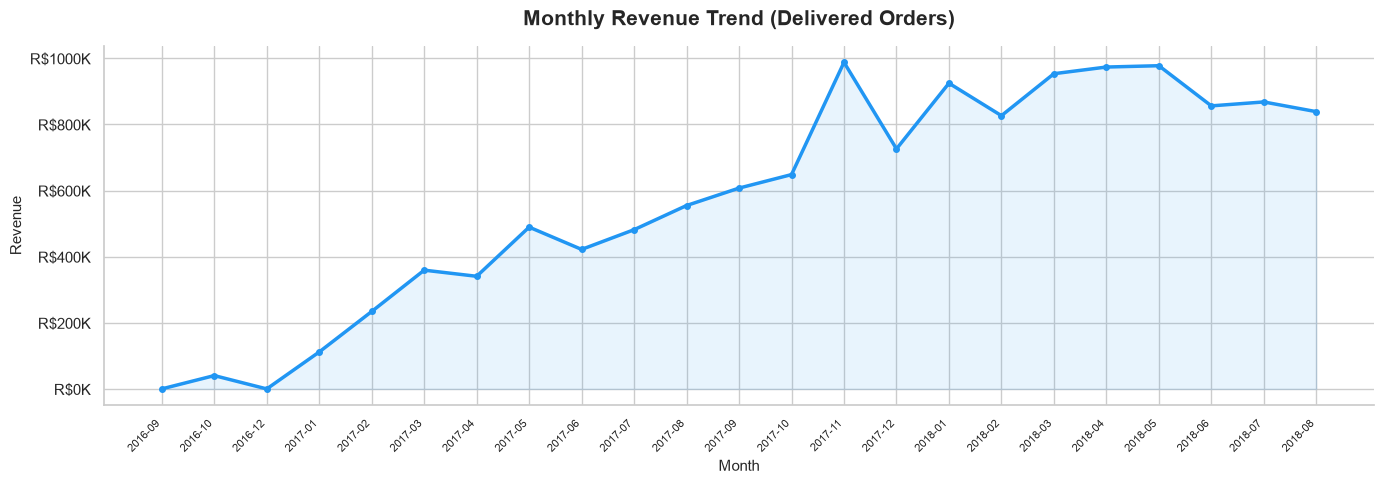

Chart saved to screenshots/


In [3]:
import os
os.makedirs("screenshots", exist_ok=True)

# Group by month, sum the revenue
monthly_revenue = (df.groupby("order_month")["price"]
                     .sum()
                     .reset_index())

# Convert Period to string for cleaner x-axis labels
monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

# ── Draw ──
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_revenue["order_month"], 
        monthly_revenue["price"], 
        color="#2196F3", linewidth=2.5, marker="o", markersize=4)

ax.fill_between(range(len(monthly_revenue)), 
                monthly_revenue["price"], 
                alpha=0.1, color="#2196F3")

# Format y-axis as currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R${x/1000:.0f}K"))

# Rotate x-axis labels so they don't overlap
plt.xticks(range(len(monthly_revenue)), 
           monthly_revenue["order_month"], 
           rotation=45, ha="right", fontsize=8)

ax.set_title("Monthly Revenue Trend (Delivered Orders)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Revenue", fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\03_Graphs\\01_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to screenshots/")

Chart 2: Top 10 Product Categories by Revenue:

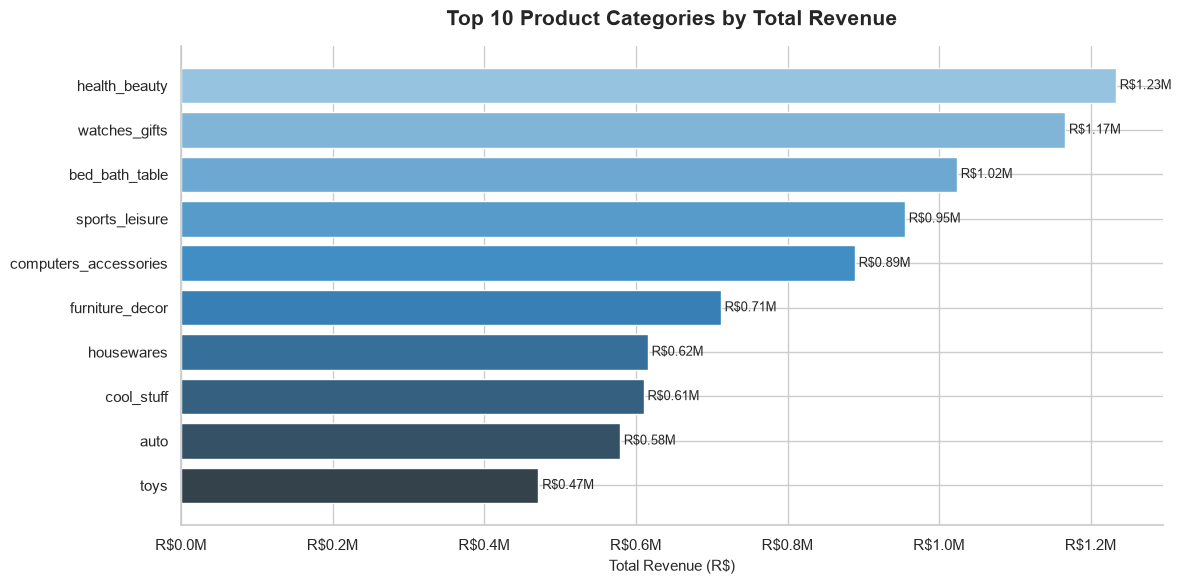

In [4]:
# Use English category names; fall back to Portuguese if translation missing
df["category_display"] = df["product_category_name_english"].fillna(
                          df["product_category_name"])

top_categories = (df.groupby("category_display")["price"]
                    .sum()
                    .sort_values(ascending=False)
                    .head(10)
                    .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_categories["category_display"], 
               top_categories["price"],
               color=sns.color_palette("Blues_d", 10))

# Add value labels at the end of each bar
for bar, val in zip(bars, top_categories["price"]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"R${val/1_000_000:.2f}M", va="center", fontsize=9)

ax.set_title("Top 10 Product Categories by Total Revenue", 
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Total Revenue (R$)", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()  # Highest revenue at the top
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R${x/1_000_000:.1f}M"))

sns.despine()
plt.tight_layout()
plt.savefig("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\03_Graphs\\02_top_categories_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 3: Revenue by Brazilian State:

C:\Users\HOLE\AppData\Local\Temp\ipykernel_4104\2034176115.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_revenue, x="customer_state", y="price",


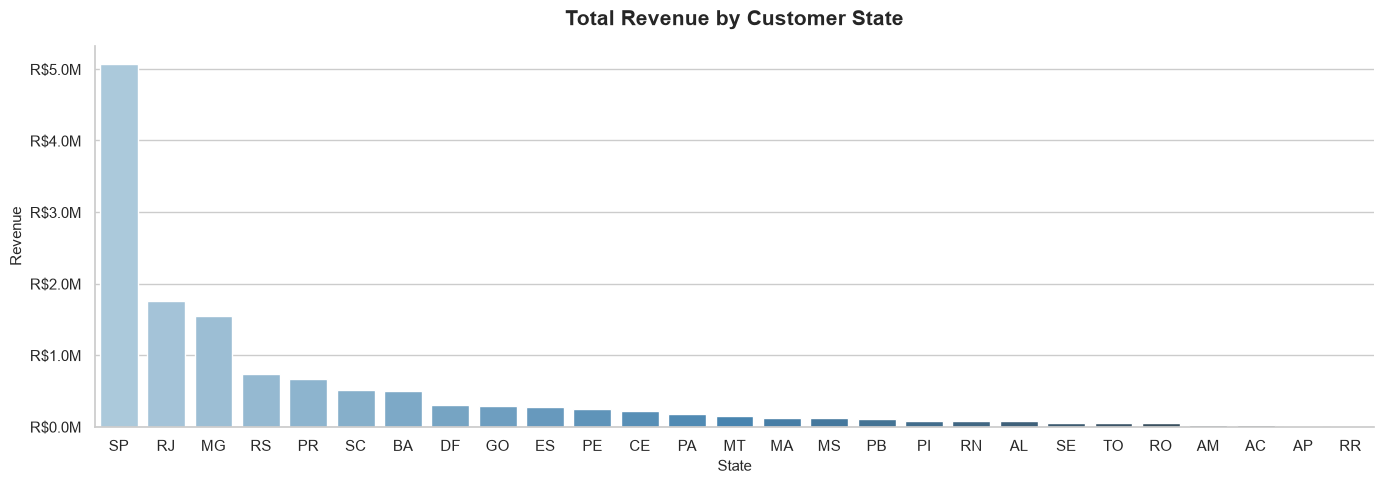

In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib") 
state_revenue = (df.groupby("customer_state")["price"]
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(data=state_revenue, x="customer_state", y="price", 
            palette="Blues_d", ax=ax)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"R${x/1_000_000:.1f}M"))

ax.set_title("Total Revenue by Customer State", 
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("Revenue", fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\03_Graphs\\03_revenue_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

 Chart 4: Order Status Breakdown:

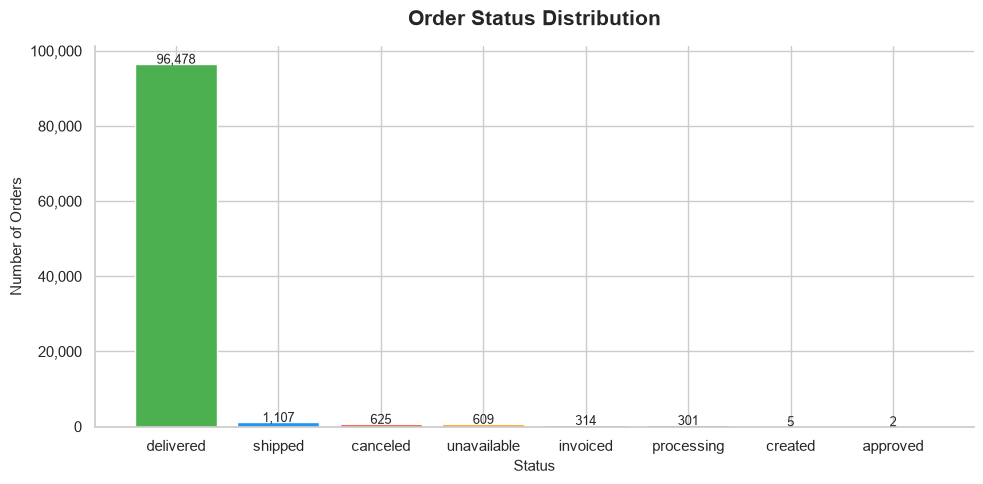

In [6]:
status_counts = orders["order_status"].value_counts().reset_index()
status_counts.columns = ["status", "count"]

fig, ax = plt.subplots(figsize=(10, 5))

colors = {"delivered": "#4CAF50", "shipped": "#2196F3", 
          "canceled": "#F44336", "unavailable": "#FF9800",
          "processing": "#9C27B0", "invoiced": "#00BCD4",
          "approved": "#8BC34A", "created": "#FFC107"}

bar_colors = [colors.get(s, "#888888") for s in status_counts["status"]]

bars = ax.bar(status_counts["status"], status_counts["count"], color=bar_colors)

for bar, val in zip(bars, status_counts["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}", ha="center", fontsize=9)

ax.set_title("Order Status Distribution", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Status", fontsize=11)
ax.set_ylabel("Number of Orders", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.savefig("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\03_Graphs\\04_order_status.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 5: Review Score Distribution:

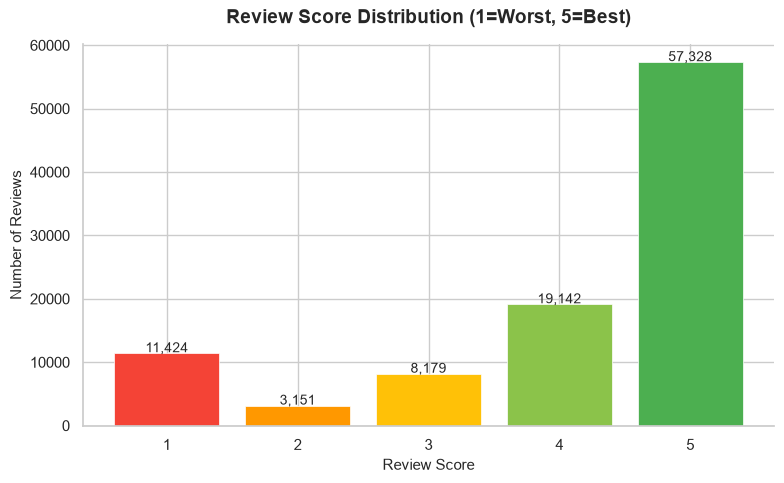

Average review score: 4.09 / 5.00
Percentage of 4 or 5 star reviews: 77.1%


In [7]:
review_counts = reviews["review_score"].value_counts().sort_index().reset_index()
review_counts.columns = ["score", "count"]

score_colors = {1:"#F44336", 2:"#FF9800", 3:"#FFC107", 4:"#8BC34A", 5:"#4CAF50"}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(review_counts["score"], review_counts["count"],
              color=[score_colors[s] for s in review_counts["score"]],
              edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, review_counts["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f"{val:,}", ha="center", fontsize=10)

ax.set_title("Review Score Distribution (1=Worst, 5=Best)", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Review Score", fontsize=11)
ax.set_ylabel("Number of Reviews", fontsize=11)
ax.set_xticks([1, 2, 3, 4, 5])
sns.despine()
plt.tight_layout()
plt.savefig("C:\\Users\\HOLE\\DATA ANALYST\\RetailPulseAI - Project\\03_Graphs\\05_review_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
avg_score = reviews["review_score"].mean()
pct_positive = (reviews["review_score"] >= 4).mean() * 100
print(f"Average review score: {avg_score:.2f} / 5.00")
print(f"Percentage of 4 or 5 star reviews: {pct_positive:.1f}%")